In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from PIL import Image
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import f1_score, accuracy_score

import time


In [2]:
import torch
import numpy as np
import random

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

In [3]:
# ==========================
# Load CSV
# ==========================
train_df = pd.read_csv(r"/home/g6422078/Data Splitting/df_train.csv")
val_df = pd.read_csv(r"/home/g6422078/Data Splitting/df_val.csv")
test_df = pd.read_csv(r"/home/g6422078/Data Splitting/df_test.csv")

In [26]:
test_df.head()

,image_path,Cluster
0,/home/g6422078/Data Preprocessing/Training Set...,4
1,/home/g6422078/Data Preprocessing/Training Set...,2
2,/home/g6422078/Data Preprocessing/Training Set...,2
3,/home/g6422078/Data Preprocessing/Training Set...,0
4,/home/g6422078/Data Preprocessing/Training Set...,3


In [4]:
model_names = ['shufflenet', 'mobilenet', 'squeezenet', 'efficientnet']
model_categories = ['best_tuned']# , 'baseline']

# mapping folder evaluasi tiap model
evaluation_dirs_baseline = {
    "mobilenet": "/home/g6422078/Evaluation/Mobilenet V3-Small/Baseline",
    "squeezenet": "/home/g6422078/Evaluation/SqueezeNet V1.1/Baseline",
    "shufflenet": "/home/g6422078/Evaluation/ShuffleNetV2-x0.5/Baseline",
    "efficientnet": "/home/g6422078/Evaluation/EfficientNet-Lite0/Baseline"
}

evaluation_dirs_best = {
    "mobilenet": "/home/g6422078/Evaluation/Mobilenet V3-Small/Best Model",
    "squeezenet": "/home/g6422078/Evaluation/SqueezeNet V1.1/Best Model",
    "shufflenet": "/home/g6422078/Evaluation/ShuffleNetV2-x0.5/Best Model",
    "efficientnet": "/home/g6422078/Evaluation/EfficientNet-Lite0/Best Model"
}

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 


In [6]:
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms

class CustomDataset(Dataset):
    def __init__(self, df):
        self.df = df
        self.transform = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["image_path"]
        labels = self.df.iloc[idx]["Cluster"]
        # print(img_path)  

        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)

        return img, labels

from torch.utils.data import DataLoader

train_dataset = CustomDataset(train_df)
#train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = CustomDataset(val_df)
#val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_dataset = CustomDataset(test_df)
#test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
# build model
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from efficientnet_lite import build_efficientnet_lite
from torchvision.models import squeezenet1_1, SqueezeNet1_1_Weights
from torchvision.models import shufflenet_v2_x0_5, ShuffleNet_V2_X0_5_Weights
model_names = ['mobilenet','squeezenet','shufflenet','efficientnet'] 

def build_model(model_name, device, dropout):
    # === mobilenet ===
    if model_name == 'mobilenet': 
        #load model
        model = mobilenet_v3_small(weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1)

        # modify the final layer (classifier) to make it has an output of 5 classes
        in_features_mobilenet = model.classifier[-1].in_features # ambil jumlah input feature dari layer terakhir

        model.classifier[-1] = nn.Sequential( #replace final layer
            nn.Dropout(p=dropout), #replace dropout
            nn.Linear(in_features_mobilenet, 5) # ubah jml kelas pada classifier menjadi 5
        )

    # === efficientnet ===
    elif model_name == 'efficientnet':
        # build model 
        model = build_efficientnet_lite('efficientnet_lite0', 1000) # 1000 features to load the weight. 1000 karena data yang digunakan untuk melatih model pretrained (which is yang membentuk weight model saat ini), yakni ImageNet, memiliki 1000 kelas

        # load weight
        model.load_state_dict(torch.load('efficientnet_lite0.pth', map_location = device))

        # modify classifier
        in_features_efficientnet = model.fc.in_features 
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features_efficientnet, 5)
        )
    
    # === squeezenet ===
    elif model_name == 'squeezenet':
        # load model 
        model = squeezenet1_1(weights = SqueezeNet1_1_Weights.IMAGENET1K_V1)

        # modify the final layer (classifier) to make it has an output of 5 classes
        in_channels_squeezenet_v1_1 = model.classifier[1].in_channels # ambil jumlah input channel (kalo conv2d pake channels, bukan features) dari layer terakhir

        model.classifier[1] = nn.Conv2d( # pake 1, bukan -1. but why?
            in_channels_squeezenet_v1_1, 
            5,
            kernel_size=(1,1) # kenapa pake ukuran kernel 1,1? 
        )

        # tambahkan layer dropout di depan classifier. layer dropout harus ditaruh di sini karena kalo dropout dulu baru nn.Conv2d, nanti overwritten shg dropout yang kita tambahin hilang begitu saja 
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout), # layer baru
            *model.classifier # iterate over semua layer lama
        )
        '''
        output:
        Dropout (baru)
        Dropout (lama)
        Conv2d
        ReLU
        AdaptiveAvgPool2d
        '''        
    
    # === shufflenet ===
    elif model_name == 'shufflenet':
        #load model
        model = shufflenet_v2_x0_5(weights = ShuffleNet_V2_X0_5_Weights.IMAGENET1K_V1)

        # modify the final layer (classifier) to make it has an output of 5 classes
        in_features_shufflenetv2x05 = model.fc.in_features #  Untuk shufflenet, pakenya bukan "classifier[-1]", tetapi "fc" (fully connected. basically classifier)

        model.fc = nn.Sequential( #replace final layer
            nn.Dropout(p=dropout), #replace dropout
            nn.Linear(in_features_shufflenetv2x05, 5) # ubah jml kelas pada classifier menjadi 5
        )

    return model

## Reka ulang untuk dapetin plot loss dan akurasi through epochs dan waktu training

In [ ]:
# train and validation using BASELINE MODEL

import copy

# training and validation function

def train_and_evaluate (model_name, model, train_loader, val_loader, optimizer, criterion, device):
    model.to(device)
    
    # create empty list to store useful value (it's helpful for tracking model progress)
    epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values = [], [], [], [], [], [], [] 
    
    # inisiasi variabel.#since kita mau maksimalin f1, maka kita gak cari loss paling minimum, merely nyari nilai loss ketika f1 maksimum (ketahui bahwa f1 score maksimum tidak selalu berarti loss minimum)
    best_f1 = float("-inf")
    epoch_best_f1 = None
    val_loss_best_f1 = None
    train_loss_best_f1 = None
    best_model_state = None
    
    # calculate the number of weights in the model
    params_no_bias = [p for n, p in model.named_parameters() if 'bias' not in n] # model.named_parameters() me-return pasangan (name, parameters) yang dalam koode ini, dimisalkan sebagai n dan p
    
    # tambahin kode buat ngitung waktu training
    # timer starts
    start_time = time.time()
    
    for epoch in range(100):
        # === TRAINING ===
        
        # reset nilai loss val dan train menjadi 0 setiap terjadi pengulangan epoch 
        val_loss = 0
        train_loss = 0
        
        # create empty list to store all_preds and all_labels per epoch when training model
        all_preds_training, all_labels_training = [], []

        
        # put model in training mode 
        model.train()
        
        # forward & backward propagation across batches 
        for imgs, labels in train_loader: # iterate over batches from DataLoader
            imgs, labels = imgs.to(device), labels.to(device)
            
            optimizer.zero_grad() # optimizer zero grad
            outputs = model(imgs) # forward pass
            if model_name == "squeezenet": # flatten untuk mengubah output model squeezenet dari [batch, jumlah kelas, 1, 1] menjadi [batch, jumlah kelas] yang bisa diterima oleh loss function crossentropy loss 
                outputs = outputs.view(outputs.size(0), -1)
            loss = criterion(outputs,labels) # calculate loss
                        
            loss.backward() # backpropagation on the loss function
            optimizer.step() # gradient descent 
            train_loss += loss.item() # total loss dari keseluruhan batches. .item() mengubah tensor menjadi float
            
            preds = torch.argmax(outputs, dim=1).cpu().numpy() # Ambil kelas dengan probabilitas tertinggi dari output model, ubah jadi CPU (karena .numpy() hanya bisa dipakai di CPU), kemudian ubah jadi array NumPy 

            # accumulate predictions and labels into a single Python list across multiple batches
            all_preds_training.extend(preds)
            all_labels_training.extend(labels.cpu().numpy()) 
        avg_train_loss = train_loss/len(train_loader) # average loss across batches
                
        # calculate macro average train f1-score
        f1_train_epoch = f1_score(all_labels_training, all_preds_training, average='macro') # train f1 score hanya digunakan untuk plotting untuk dibandingkan dengan val, adapun f1 score yang dipake untuk memilih model adalah f1 score val
        
        # calculate train acc
        acc_train_epoch = accuracy_score(all_labels_training, all_preds_training)
        
        
        # === VALIDATION ===
        # create empty list to store all_preds and all_labels per epoch when validating model
        all_preds_val, all_labels_val = [], []
        # put model in eval mode 
        model.eval()

        with torch.no_grad(): # turn on no_grad() for faster performance bc it disables gradient tracking functionality (gradient tracking is not needed for inference)
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs) # forward pass
                if model_name == "squeezenet": # flatten untuk mengubah output model squeezenet dari [batch, jumlah kelas, 1, 1] menjadi [batch, jumlah kelas] yang bisa diterima oleh loss function crossentropy loss 
                    outputs = outputs.view(outputs.size(0), -1)
                    
                #calculate loss
                loss = criterion(outputs, labels) 
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1).cpu().numpy() # Ambil kelas dengan probabilitas tertinggi dari output model, ubah jadi CPU (karena .numpy() hanya bisa dipakai di CPU), kemudian ubah jadi array NumPy 

                # accumulate predictions and labels into a single Python list across multiple batches
                all_preds_val.extend(preds)
                all_labels_val.extend(labels.cpu().numpy()) 
        avg_val_loss = val_loss/len(val_loader)
        
        # calculate macro average val f1-score
        f1_val_epoch = f1_score(all_labels_val, all_preds_val, average='macro')
        
        # calculate train acc
        acc_val_epoch = accuracy_score(all_labels_val, all_preds_val)
        
        
        # choose best f1 score, train_loss_best_f1, dan val_loss_best_f1
        if f1_val_epoch > best_f1: 
            best_f1 = f1_val_epoch
            epoch_best_f1 = epoch
            train_loss_best_f1 = avg_train_loss #train_loss_when_f1_reached_its_max_value
            val_loss_best_f1 = avg_val_loss #val_loss_when_f1_reached_its_max_value
            best_model_state = copy.deepcopy(model.state_dict()) #copy.deepcopy(model.state_dict()) # menyimpan weight, bias, buffer (BatchNorm, dll.) setelah model dilatih dan dievaluasi. berbeda dengan best_config yang menyimpan konfigurasi hyperparameter (learning rate, optimizer, dll) model
        
        #simpan important values setiap epoch untuk plotting curve nanti
        epoch_count.append(epoch)
        train_loss_values.append(avg_train_loss)
        val_loss_values.append(avg_val_loss)
        f1_train_values.append(f1_train_epoch)
        f1_val_values.append(f1_val_epoch)
        acc_train_values.append(acc_train_epoch)
        acc_val_values.append(acc_val_epoch)
        # print out what's happening every 10 epochs 
        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Categorical Cross Entropy Train Loss: {avg_train_loss:.4f} | Categorical Cross Entropy Val Loss: {avg_val_loss:.4f} | F1-Score = {f1_val_epoch:.4f}")
    
    # timer ends
    end_time = time.time()
    
    total_time_seconds = end_time - start_time
    #total_time_minutes = total_time_seconds / 60
    
    print(f"  Training time    : {total_time_seconds:.2f} seconds")
    #print(f"  Training time    : {total_time_minutes:.2f} minutes")
    print("-" * 40)

    return epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds


In [ ]:
# train and validation using BEST MODEL

import copy

# training and validation function

def train_and_evaluate (model_name, model, train_loader, val_loader, optimizer, criterion, device, l1_lambda, l2_lambda):
    model.to(device)
    
    # create empty list to store useful value (it's helpful for tracking model progress)
    epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values = [], [], [], [], [], [], [] 
    
    # inisiasi variabel.#since kita mau maksimalin f1, maka kita gak cari loss paling minimum, merely nyari nilai loss ketika f1 maksimum (ketahui bahwa f1 score maksimum tidak selalu berarti loss minimum)
    best_f1 = float("-inf")
    epoch_best_f1 = None
    val_loss_best_f1 = None
    train_loss_best_f1 = None
    best_model_state = None
    
    # calculate the number of weights in the model
    params_no_bias = [p for n, p in model.named_parameters() if 'bias' not in n] # model.named_parameters() me-return pasangan (name, parameters) yang dalam koode ini, dimisalkan sebagai n dan p
    
    # tambahin kode buat ngitung waktu training
    # timer starts
    start_time = time.time()
    
    for epoch in range(100):
        # === TRAINING ===
        
        # reset nilai loss val dan train menjadi 0 setiap terjadi pengulangan epoch 
        val_loss = 0
        train_loss = 0
        
        # create empty list to store all_preds and all_labels per epoch when training model
        all_preds_training, all_labels_training = [], []

        
        # put model in training mode 
        model.train()
        
        # forward & backward propagation across batches 
        for imgs, labels in train_loader: # iterate over batches from DataLoader
            imgs, labels = imgs.to(device), labels.to(device)
            
            optimizer.zero_grad() # optimizer zero grad
            outputs = model(imgs) # forward pass
            if model_name == "squeezenet": # flatten untuk mengubah output model squeezenet dari [batch, jumlah kelas, 1, 1] menjadi [batch, jumlah kelas] yang bisa diterima oleh loss function crossentropy loss 
                outputs = outputs.view(outputs.size(0), -1)
            loss = criterion(outputs,labels) # calculate loss
            
            # apply elasticnet regularization
            '''
            for name, weights in model.named_parameters():
                if 'bias' not in name:
                    l1_weights_sum = torch.sum(torch.abs(weights))
                    l2_weight_sum = torch.sum(torch.square(weights))
                    l1_term = l1_term + l1_weights_sum
                    l2_term = l2_term + l2_weight_sum
            l1_term = l1_term/nweights
            l2_term = l2_term/nweights
            '''
            l1_term = sum(torch.sum(torch.abs(p)) for p in params_no_bias) / len(params_no_bias)
            l2_term = sum(torch.sum(torch.square(p)) for p in params_no_bias) / len(params_no_bias)

  
            loss = loss + l1_lambda * l1_term + l2_lambda * l2_term
      
            
            loss.backward() # backpropagation on the loss function
            optimizer.step() # gradient descent 
            train_loss += loss.item() # total loss dari keseluruhan batches. .item() mengubah tensor menjadi float
            
            preds = torch.argmax(outputs, dim=1).cpu().numpy() # Ambil kelas dengan probabilitas tertinggi dari output model, ubah jadi CPU (karena .numpy() hanya bisa dipakai di CPU), kemudian ubah jadi array NumPy 

            # accumulate predictions and labels into a single Python list across multiple batches
            all_preds_training.extend(preds)
            all_labels_training.extend(labels.cpu().numpy()) 
        avg_train_loss = train_loss/len(train_loader) # average loss across batches
                
        # calculate macro average train f1-score
        f1_train_epoch = f1_score(all_labels_training, all_preds_training, average='macro') # train f1 score hanya digunakan untuk plotting untuk dibandingkan dengan val, adapun f1 score yang dipake untuk memilih model adalah f1 score val
        
        # calculate train acc
        acc_train_epoch = accuracy_score(all_labels_training, all_preds_training)
        
        
        # === VALIDATION ===
        # create empty list to store all_preds and all_labels per epoch when validating model
        all_preds_val, all_labels_val = [], []
        # put model in eval mode 
        model.eval()

        with torch.no_grad(): # turn on no_grad() for faster performance bc it disables gradient tracking functionality (gradient tracking is not needed for inference)
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs) # forward pass
                if model_name == "squeezenet": # flatten untuk mengubah output model squeezenet dari [batch, jumlah kelas, 1, 1] menjadi [batch, jumlah kelas] yang bisa diterima oleh loss function crossentropy loss 
                    outputs = outputs.view(outputs.size(0), -1)
                    
                #calculate loss
                loss = criterion(outputs, labels) 
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1).cpu().numpy() # Ambil kelas dengan probabilitas tertinggi dari output model, ubah jadi CPU (karena .numpy() hanya bisa dipakai di CPU), kemudian ubah jadi array NumPy 

                # accumulate predictions and labels into a single Python list across multiple batches
                all_preds_val.extend(preds)
                all_labels_val.extend(labels.cpu().numpy()) 
        avg_val_loss = val_loss/len(val_loader)
        
        # calculate macro average val f1-score
        f1_val_epoch = f1_score(all_labels_val, all_preds_val, average='macro')
        
        # calculate train acc
        acc_val_epoch = accuracy_score(all_labels_val, all_preds_val)
        
        
        # choose best f1 score, train_loss_best_f1, dan val_loss_best_f1
        if f1_val_epoch > best_f1: 
            best_f1 = f1_val_epoch
            epoch_best_f1 = epoch
            train_loss_best_f1 = avg_train_loss #train_loss_when_f1_reached_its_max_value
            val_loss_best_f1 = avg_val_loss #val_loss_when_f1_reached_its_max_value
            best_model_state = copy.deepcopy(model.state_dict()) #copy.deepcopy(model.state_dict()) # menyimpan weight, bias, buffer (BatchNorm, dll.) setelah model dilatih dan dievaluasi. berbeda dengan best_config yang menyimpan konfigurasi hyperparameter (learning rate, optimizer, dll) model
        
        #simpan important values setiap epoch untuk plotting curve nanti
        epoch_count.append(epoch)
        train_loss_values.append(avg_train_loss)
        val_loss_values.append(avg_val_loss)
        f1_train_values.append(f1_train_epoch)
        f1_val_values.append(f1_val_epoch)
        acc_train_values.append(acc_train_epoch)
        acc_val_values.append(acc_val_epoch)
        # print out what's happening every 10 epochs 
        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Categorical Cross Entropy Train Loss: {avg_train_loss:.4f} | Categorical Cross Entropy Val Loss: {avg_val_loss:.4f} | F1-Score = {f1_val_epoch:.4f}")
    
    # timer ends
    end_time = time.time()
    
    total_time_seconds = end_time - start_time
    #total_time_minutes = total_time_seconds / 60
    
    print(f"  Training time    : {total_time_seconds:.2f} seconds")
    #print(f"  Training time    : {total_time_minutes:.2f} minutes")
    print("-" * 40)

    return epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds


In [26]:
import torch
torch.cuda.empty_cache()

In [16]:
torch.backends.cudnn.enabled = False


Running: BS=32, DO=0.2, OPT=adam, LR=0.001, model=shufflenet
Epoch: 0 | Categorical Cross Entropy Train Loss: 1.2221 | Categorical Cross Entropy Val Loss: 1.1210 | F1-Score = 0.5224
Epoch: 10 | Categorical Cross Entropy Train Loss: 0.2693 | Categorical Cross Entropy Val Loss: 2.3382 | F1-Score = 0.4882
Epoch: 20 | Categorical Cross Entropy Train Loss: 0.1809 | Categorical Cross Entropy Val Loss: 2.5323 | F1-Score = 0.5117
Epoch: 30 | Categorical Cross Entropy Train Loss: 0.1445 | Categorical Cross Entropy Val Loss: 2.8799 | F1-Score = 0.5151
Epoch: 40 | Categorical Cross Entropy Train Loss: 0.1901 | Categorical Cross Entropy Val Loss: 2.7692 | F1-Score = 0.5210
Epoch: 50 | Categorical Cross Entropy Train Loss: 0.1359 | Categorical Cross Entropy Val Loss: 3.4177 | F1-Score = 0.4916
Epoch: 60 | Categorical Cross Entropy Train Loss: 0.1024 | Categorical Cross Entropy Val Loss: 3.3996 | F1-Score = 0.4847
Epoch: 70 | Categorical Cross Entropy Train Loss: 0.1516 | Categorical Cross Entropy 

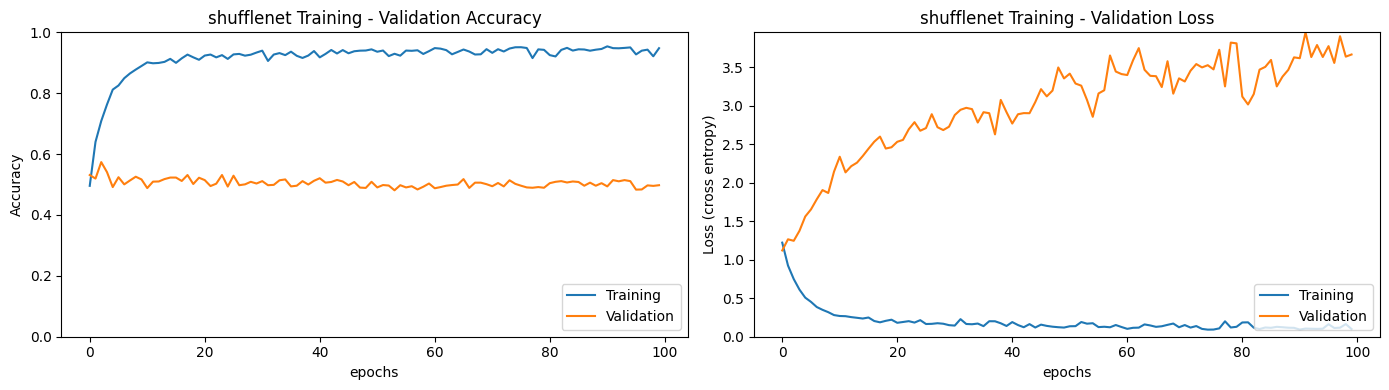


Plot saved to:
/home/g6422078/Evaluation/ShuffleNetV2-x0.5/Baseline/shufflenet_accuracy_loss_curve.png

JSON saved to:
/home/g6422078/Evaluation/ShuffleNetV2-x0.5/Baseline/shufflenet_best_model_experiment.json

Model state saved to:
/home/g6422078/Evaluation/ShuffleNetV2-x0.5/Baseline/shufflenet_best_model_state.pth

Running: BS=32, DO=0.2, OPT=adam, LR=0.001, model=mobilenet
Epoch: 0 | Categorical Cross Entropy Train Loss: 1.0537 | Categorical Cross Entropy Val Loss: 1.8138 | F1-Score = 0.3263
Epoch: 10 | Categorical Cross Entropy Train Loss: 0.2089 | Categorical Cross Entropy Val Loss: 2.9179 | F1-Score = 0.4855
Epoch: 20 | Categorical Cross Entropy Train Loss: 0.2180 | Categorical Cross Entropy Val Loss: 3.0925 | F1-Score = 0.5351
Epoch: 30 | Categorical Cross Entropy Train Loss: 0.1331 | Categorical Cross Entropy Val Loss: 3.1920 | F1-Score = 0.4977
Epoch: 40 | Categorical Cross Entropy Train Loss: 0.1488 | Categorical Cross Entropy Val Loss: 3.2787 | F1-Score = 0.5014
Epoch: 50 |

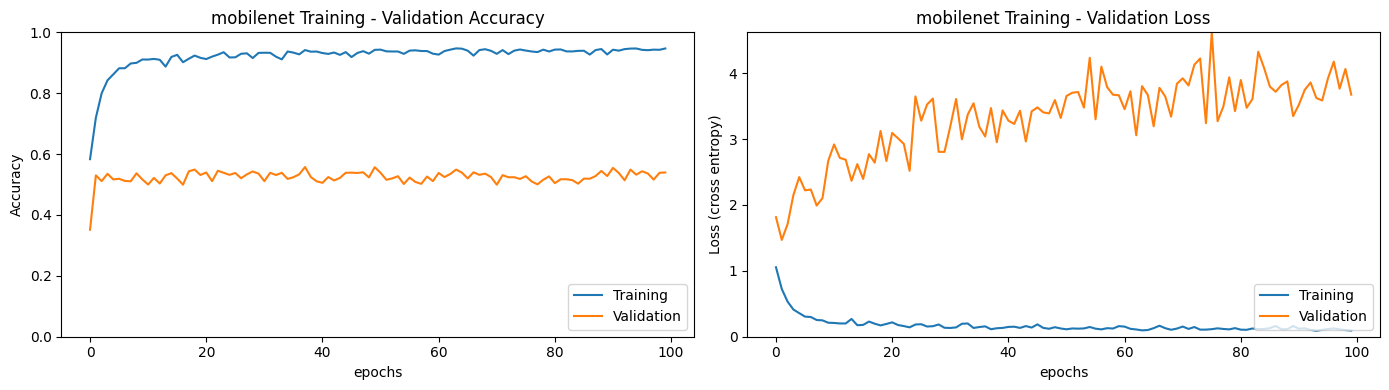


Plot saved to:
/home/g6422078/Evaluation/Mobilenet V3-Small/Baseline/mobilenet_accuracy_loss_curve.png

JSON saved to:
/home/g6422078/Evaluation/Mobilenet V3-Small/Baseline/mobilenet_best_model_experiment.json

Model state saved to:
/home/g6422078/Evaluation/Mobilenet V3-Small/Baseline/mobilenet_best_model_state.pth

Running: BS=32, DO=0.2, OPT=adam, LR=0.001, model=squeezenet
Epoch: 0 | Categorical Cross Entropy Train Loss: 1.5828 | Categorical Cross Entropy Val Loss: 1.5373 | F1-Score = 0.1749
Epoch: 10 | Categorical Cross Entropy Train Loss: 1.0939 | Categorical Cross Entropy Val Loss: 1.3988 | F1-Score = 0.3608
Epoch: 20 | Categorical Cross Entropy Train Loss: 0.7033 | Categorical Cross Entropy Val Loss: 1.4319 | F1-Score = 0.4859
Epoch: 30 | Categorical Cross Entropy Train Loss: 0.4397 | Categorical Cross Entropy Val Loss: 2.1790 | F1-Score = 0.4417
Epoch: 40 | Categorical Cross Entropy Train Loss: 0.2986 | Categorical Cross Entropy Val Loss: 2.9647 | F1-Score = 0.4364
Epoch: 50 

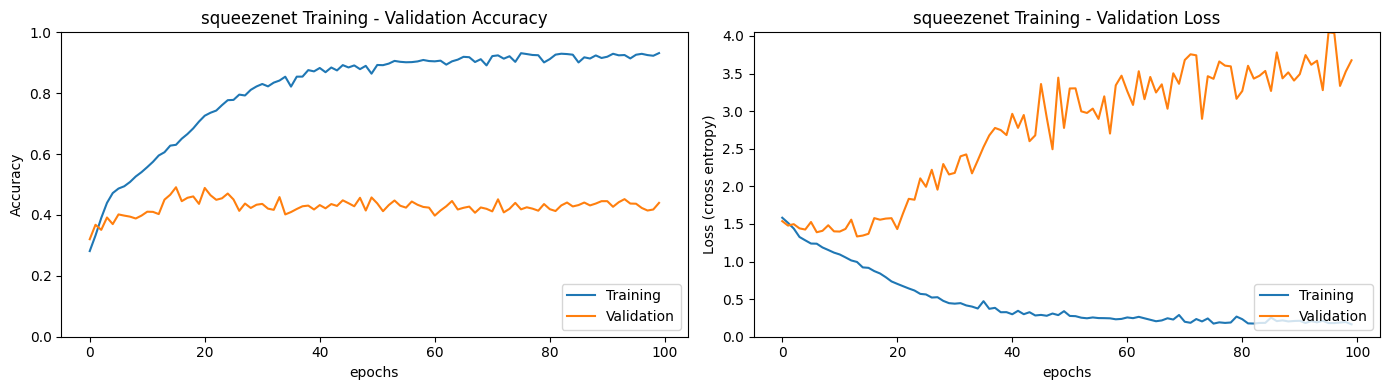


Plot saved to:
/home/g6422078/Evaluation/SqueezeNet V1.1/Baseline/squeezenet_accuracy_loss_curve.png

JSON saved to:
/home/g6422078/Evaluation/SqueezeNet V1.1/Baseline/squeezenet_best_model_experiment.json

Model state saved to:
/home/g6422078/Evaluation/SqueezeNet V1.1/Baseline/squeezenet_best_model_state.pth

Running: BS=32, DO=0.2, OPT=adam, LR=0.001, model=efficientnet
Epoch: 0 | Categorical Cross Entropy Train Loss: 1.1500 | Categorical Cross Entropy Val Loss: 1.6503 | F1-Score = 0.4774
Epoch: 10 | Categorical Cross Entropy Train Loss: 0.3083 | Categorical Cross Entropy Val Loss: 2.4093 | F1-Score = 0.4935
Epoch: 20 | Categorical Cross Entropy Train Loss: 0.1928 | Categorical Cross Entropy Val Loss: 2.5859 | F1-Score = 0.5080
Epoch: 30 | Categorical Cross Entropy Train Loss: 0.1777 | Categorical Cross Entropy Val Loss: 3.4874 | F1-Score = 0.5178
Epoch: 40 | Categorical Cross Entropy Train Loss: 0.1302 | Categorical Cross Entropy Val Loss: 4.6744 | F1-Score = 0.4888
Epoch: 50 | Ca

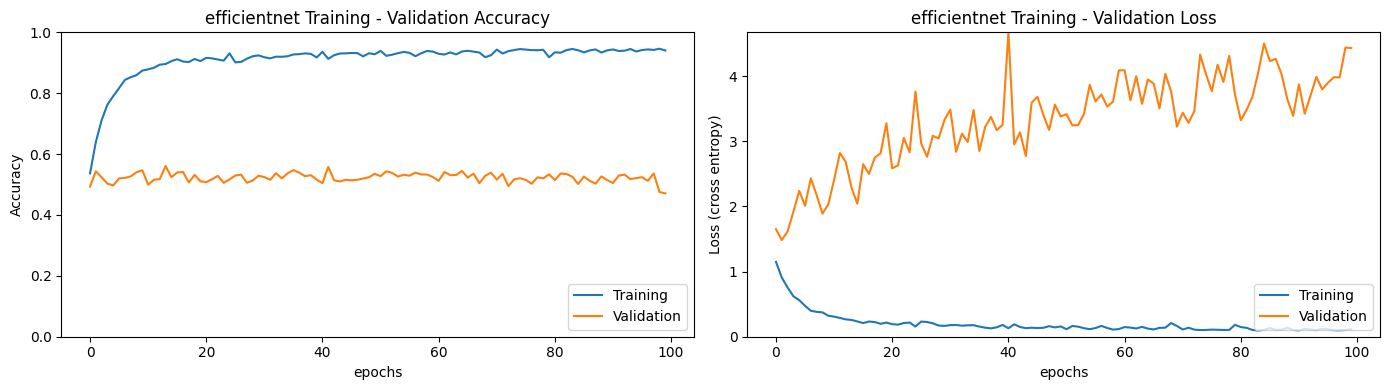


Plot saved to:
/home/g6422078/Evaluation/EfficientNet-Lite0/Baseline/efficientnet_accuracy_loss_curve.png

JSON saved to:
/home/g6422078/Evaluation/EfficientNet-Lite0/Baseline/efficientnet_best_model_experiment.json

Model state saved to:
/home/g6422078/Evaluation/EfficientNet-Lite0/Baseline/efficientnet_best_model_state.pth


In [ ]:

# grid search BASELINE MODEL



def run_best_model_experiment(model_name, dropout, batch_size, lr, opt_name, device): # ini namanya best_model karena blm diganti, tp ini untuk baseline model karena ga ada l1 dan l2 untuk regularisasi
    print(f"\nRunning: BS={batch_size}, DO={dropout}, OPT={opt_name}, LR={lr}, model={model_name}")

    # build model --> should i call it all at once??
    model = build_model(model_name, device, dropout) 
    
    # dataloader untuk mendefinisikan aturan batching
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    
    # optimizer
    if opt_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss()
            
    # train and evaluate seluruh hyperparameter --> ini kan cuma nerima 1 model, gimana caranya supaya model yang ada 4 itu (fungsi build_model memuntahkan 4 model) dimasukkinnya satu per satu ke fungsi train_and_evaluate 
    epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds = train_and_evaluate(model_name, model, train_loader, val_loader, optimizer, criterion, device)    
    
    print(f"Training and Validation Done in {total_time_seconds} seconds.")
    
    # ambil acc dari best epoch sebagai representasi akurasi pada kombinasi hyperparameter yang sedang berlangsung
    print(f"Training Accuracy =  {acc_train_values[epoch_best_f1]}")
    print(f"Validation Accuracy = {acc_val_values[epoch_best_f1]}")
    
    
    # plot hisstory of accuracy and loss value of each best model --> aku nyimpen histori dari f1 score doang, jadi ini nanti aja dijalanin manual karena harus revisi kode supaya nyimpen riwayat loss juga, kelamaan jir dan kalo ada cara yang lebih gampang mari kita pake cara tersebut. tapi anehnya tuh ada sih di folder plot hasil plotting-nya. yaudahlah nanti tinggal run ulang lagi untuk best config tersebut. btw untuk dapetin akurasi juga, nanti bisa plot akurasi dari best config itu. nanti tampilin plot-nya plot akurasi aja. jadi untuk grafik ini, pr-nya tampilin plot akurasi dari best config
    # PR: jadiin plot akurasi dan loss (CHECKED)
    acc_train = acc_train_values
    acc_val = acc_val_values

    train_loss = train_loss_values
    val_loss = val_loss_values

    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14, 4))

    #plot accuracy score evolution through epochs
    ax1.plot(acc_train, label='Training')
    ax1.plot(acc_val, label='Validation')
    ax1.legend(loc='lower right')
    ax1.set(ylabel='Accuracy', 
            xlabel = 'epochs', 
            title=f'{model_name} Training - Validation Accuracy')
    ax1.set_ylim(0,1)

    #plot loss evolution through epochs
    ax2.plot(train_loss, label='Training')
    ax2.plot(val_loss, label='Validation')
    ax2.legend(loc='lower right')
    ax2.set(ylabel='Loss (cross entropy)', 
            xlabel='epochs',
            title=f'{model_name} Training - Validation Loss', 
            ylim=(0, max(max(train_loss), max(val_loss)))
            )
    
    plt.tight_layout()
    
    # Simpan plot jadi PNG (manual) --> simpan jadi PNG sebelum plt.show() krn pd bbrp backend, plt.show() itu menampilkan terus clear figure, jadi nanti pas di-save, gambarnya bisa kosong
    #plot_path = os.path.join(plots_dir, f"best_{model_name}_acc_loss_plot.png")
    #plt.savefig(plot_path)
    
    # ambil direktori save
    save_dir = evaluation_dirs_baseline[model_name]

    # bikin folder kalau belum ada
    os.makedirs(save_dir, exist_ok=True)

    # path save plot
    plot_path = os.path.join(
        save_dir,
        f"{model_name}_accuracy_loss_curve.png"
    )

    # SAVE FIGURE DULU
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')

    # tampilkan
    plt.show()

    # close biar memory gak numpuk
    plt.close()

    print(f"\nPlot saved to:")
    print(plot_path)
    
    #plt.close()
    
    
    # ambil save directory sesuai model
    save_dir = evaluation_dirs_baseline[model_name]

    # bikin folder kalau belum ada
    os.makedirs(save_dir, exist_ok=True)

    # =========================
    # SAVE MODEL STATE (.pth)
    # =========================
    model_state_path = os.path.join(
        save_dir,
        f"{model_name}_best_model_state.pth"
    )

    torch.save(best_model_state, model_state_path)

    # =========================
    # SAVE RESULT JSON --> ini harusnya dipisah antara baseline sama best model. di kode ini, baseline disimpan sebagai best model, tapi disimpennya di folder baseline. yang di baseline udah aku ubah manual namanya from {model_name}_best_model_experiment.json --> {model_name}_baseline_experiment.json (ini namanya emang ga nyambung, harusnya bukan experiment, tapi yaudah for now as is aja dulu) dan efficientnet_best_model_state.pth -->  efficientnet_baseline_state.pth
    # =========================
    result_experiment = {
        "model_name": model_name,

        "hyperparameters": {
            "dropout": dropout,
            "batch_size": batch_size,
            "learning_rate": lr,
            "optimizer": opt_name
        },

        "epoch_count": epoch_count,

        "train_loss_values": train_loss_values,
        "val_loss_values": val_loss_values,

        "f1_train_values": f1_train_values,
        "f1_val_values": f1_val_values,

        "acc_train_values": acc_train_values,
        "acc_val_values": acc_val_values,

        "best_f1": best_f1,
        "epoch_best_f1": epoch_best_f1,

        "val_loss_best_f1": val_loss_best_f1,
        "train_loss_best_f1": train_loss_best_f1,

        "total_time_seconds": total_time_seconds,

        # referensi lokasi .pth
        "best_model_state_path": model_state_path
    }

    # path json
    json_path = os.path.join(
        save_dir,
        f"{model_name}_best_model_experiment.json"
    )

    # save json
    with open(json_path, "w") as f:
        json.dump(result_experiment, f, indent=4)

    print(f"\nJSON saved to:")
    print(json_path)

    print(f"\nModel state saved to:")
    print(model_state_path)

    
    return epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds
    
# jalankan fungsi 
# shufflenet
# baseline model
#epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds = run_best_model_experiment(model_name="shufflenet", dropout=0.2, batch_size=32, lr=0.001, opt_name="adam", device=device)    
# best model
epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds = run_best_model_experiment(model_name="shufflenet", dropout=0.3, batch_size=16, lr=0.001, opt_name="adam", device=device)    

# mobilenet
# baseline model
#epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds = run_best_model_experiment(model_name="mobilenet", dropout=0.2, batch_size=32, lr=0.001, opt_name="adam", device=device)    
# best model
epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds = run_best_model_experiment(model_name="shufflenet", dropout=0.2, batch_size=32, lr=0.001, opt_name="adam", device=device)    

# squeezenet
# baseline model
#epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds = run_best_model_experiment(model_name="squeezenet", dropout=0.2, batch_size=32, lr=0.001, opt_name="adam", device=device)    
# best model
epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds = run_best_model_experiment(model_name="shufflenet", dropout=0.2, batch_size=32, lr=0.001, opt_name="adam", device=device)    

# efficientnet
# baseline model
#epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds = run_best_model_experiment(model_name="efficientnet", dropout=0.2, batch_size=32, lr=0.001, opt_name="adam", device=device)    
# best model
epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds = run_best_model_experiment(model_name="shufflenet", dropout=0.2, batch_size=32, lr=0.001, opt_name="adam", device=device)    




Running: BS=32, DO=0.3, OPT=adam, LR=0.0001, model=efficientnet
Epoch: 0 | Categorical Cross Entropy Train Loss: 23.7188 | Categorical Cross Entropy Val Loss: 1.2045 | F1-Score = 0.4729
Epoch: 10 | Categorical Cross Entropy Train Loss: 18.1596 | Categorical Cross Entropy Val Loss: 1.7714 | F1-Score = 0.5470
Epoch: 20 | Categorical Cross Entropy Train Loss: 15.2887 | Categorical Cross Entropy Val Loss: 2.0061 | F1-Score = 0.5272
Epoch: 30 | Categorical Cross Entropy Train Loss: 13.2013 | Categorical Cross Entropy Val Loss: 2.2313 | F1-Score = 0.5376
Epoch: 40 | Categorical Cross Entropy Train Loss: 11.6478 | Categorical Cross Entropy Val Loss: 2.5446 | F1-Score = 0.5072
Epoch: 50 | Categorical Cross Entropy Train Loss: 10.4789 | Categorical Cross Entropy Val Loss: 2.6190 | F1-Score = 0.5309
Epoch: 60 | Categorical Cross Entropy Train Loss: 9.5195 | Categorical Cross Entropy Val Loss: 2.3147 | F1-Score = 0.5177
Epoch: 70 | Categorical Cross Entropy Train Loss: 8.8055 | Categorical Cross

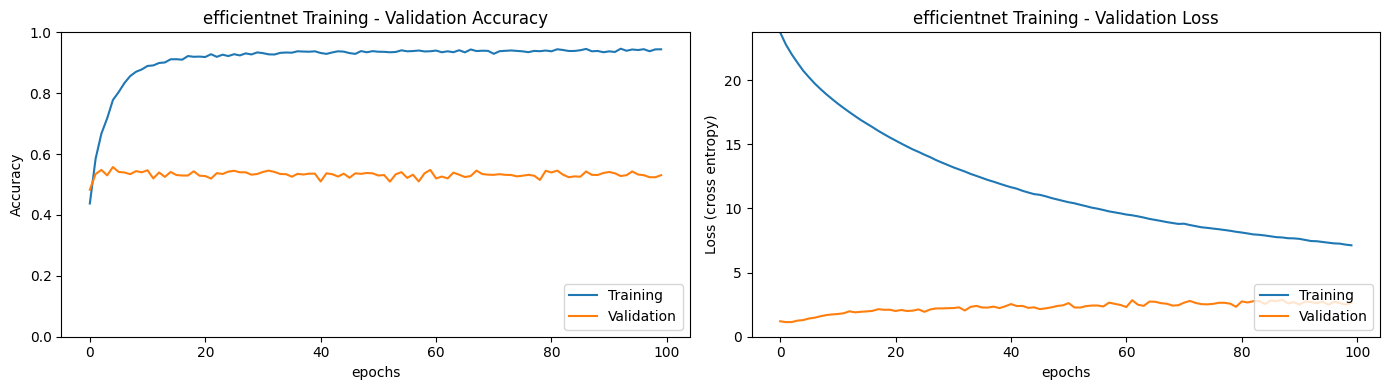


Plot saved to:
/home/g6422078/Evaluation/EfficientNet-Lite0/Best Model/efficientnet_accuracy_loss_curve.png

JSON saved to:
/home/g6422078/Evaluation/EfficientNet-Lite0/Best Model/efficientnet_best_model_experiment.json

Model state saved to:
/home/g6422078/Evaluation/EfficientNet-Lite0/Best Model/efficientnet_best_model_state.pth


In [ ]:
# grid search BEST MODEL


def run_best_model_experiment(model_name, dropout, batch_size, lr, opt_name, l1_lambda, l2_lambda, device): 
    print(f"\nRunning: BS={batch_size}, DO={dropout}, OPT={opt_name}, LR={lr}, model={model_name}")

    # build model --> should i call it all at once??
    model = build_model(model_name, device, dropout)

    # dataloader untuk mendefinisikan aturan batching
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    # optimizer
    if opt_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss()

    # train and evaluate seluruh hyperparameter --> ini kan cuma nerima 1 model, gimana caranya supaya model yang ada 4 itu (fungsi build_model memuntahkan 4 model) dimasukkinnya satu per satu ke fungsi train_and_evaluate 
    epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds = train_and_evaluate(model_name, model, train_loader, val_loader, optimizer, criterion, device, l1_lambda, l2_lambda)     

    print(f"Training and Validation Done in {total_time_seconds} seconds.")
    
    # ambil acc dari best epoch sebagai representasi akurasi pada kombinasi hyperparameter yang sedang berlangsung
    print(f"Training Accuracy =  {acc_train_values[epoch_best_f1]}")
    print(f"Validation Accuracy = {acc_val_values[epoch_best_f1]}")
    
    
    # plot hisstory of accuracy and loss value of each best model --> aku nyimpen histori dari f1 score doang, jadi ini nanti aja dijalanin manual karena harus revisi kode supaya nyimpen riwayat loss juga, kelamaan jir dan kalo ada cara yang lebih gampang mari kita pake cara tersebut. tapi anehnya tuh ada sih di folder plot hasil plotting-nya. yaudahlah nanti tinggal run ulang lagi untuk best config tersebut. btw untuk dapetin akurasi juga, nanti bisa plot akurasi dari best config itu. nanti tampilin plot-nya plot akurasi aja. jadi untuk grafik ini, pr-nya tampilin plot akurasi dari best config
    # PR: jadiin plot akurasi dan loss (CHECKED)
    acc_train = acc_train_values
    acc_val = acc_val_values

    train_loss = train_loss_values
    val_loss = val_loss_values

    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14, 4))

    #plot accuracy score evolution through epochs
    ax1.plot(acc_train, label='Training')
    ax1.plot(acc_val, label='Validation')
    ax1.legend(loc='lower right')
    ax1.set(ylabel='Accuracy', 
            xlabel = 'epochs', 
            title=f'{model_name} Training - Validation Accuracy')
    ax1.set_ylim(0,1)

    #plot loss evolution through epochs
    ax2.plot(train_loss, label='Training')
    ax2.plot(val_loss, label='Validation')
    ax2.legend(loc='lower right')
    ax2.set(ylabel='Loss (cross entropy)', 
            xlabel='epochs',
            title=f'{model_name} Training - Validation Loss', 
            ylim=(0, max(max(train_loss), max(val_loss)))
            )
    
    plt.tight_layout()
    
    # (INI SIMPEN MANUAL AJA) Simpan plot jadi PNG --> simpan jadi PNG sebelum plt.show() krn pd bbrp backend, plt.show() itu menampilkan terus clear figure, jadi nanti pas di-save, gambarnya bisa kosong
    #plot_path = os.path.join(plots_dir, f"best_{model_name}_acc_loss_plot.png")
    #plt.savefig(plot_path)
    
    # ambil direktori save
    save_dir = evaluation_dirs_best[model_name]

    # bikin folder kalau belum ada
    os.makedirs(save_dir, exist_ok=True)

    # path save plot
    plot_path = os.path.join(
        save_dir,
        f"{model_name}_accuracy_loss_curve.png"
    )

    # SAVE FIGURE DULU
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')

    # tampilkan
    plt.show()

    # close biar memory gak numpuk
    plt.close()

    print(f"\nPlot saved to:")
    print(plot_path)
    
    #plt.close()
    
    
    # ambil save directory sesuai model
    save_dir = evaluation_dirs_best[model_name]

    # bikin folder kalau belum ada
    os.makedirs(save_dir, exist_ok=True)

    # =========================
    # SAVE MODEL STATE (.pth)
    # =========================
    model_state_path = os.path.join(
        save_dir,
        f"{model_name}_best_model_state.pth"
    )

    torch.save(best_model_state, model_state_path)

    # =========================
    # SAVE RESULT JSON 
    # =========================
    result_experiment = {
        "model_name": model_name,

        "hyperparameters": {
            "dropout": dropout,
            "batch_size": batch_size,
            "learning_rate": lr,
            "optimizer": opt_name
        },

        "epoch_count": epoch_count,

        "train_loss_values": train_loss_values,
        "val_loss_values": val_loss_values,

        "f1_train_values": f1_train_values,
        "f1_val_values": f1_val_values,

        "acc_train_values": acc_train_values,
        "acc_val_values": acc_val_values,

        "best_f1": best_f1,
        "epoch_best_f1": epoch_best_f1,

        "val_loss_best_f1": val_loss_best_f1,
        "train_loss_best_f1": train_loss_best_f1,

        "total_time_seconds": total_time_seconds,

        # referensi lokasi .pth
        "best_model_state_path": model_state_path
    }

    # path json
    json_path = os.path.join(
        save_dir,
        f"{model_name}_best_model_experiment.json"
    )

    # save json
    with open(json_path, "w") as f:
        json.dump(result_experiment, f, indent=4)

    print(f"\nJSON saved to:")
    print(json_path)

    print(f"\nModel state saved to:")
    print(model_state_path)

    
    return epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds
    
# jalankan fungsi 
# mobilenet
#epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds = run_best_model_experiment(model_name="mobilenet", dropout=0.3, batch_size=8, lr=0.0001, opt_name="adam", l1_lambda=0.01, l2_lambda=0.001, device=device)   

# squeezenet
#epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds = run_best_model_experiment(model_name="squeezenet", dropout=0.5, batch_size=16, lr=0.0001, opt_name="adam", l1_lambda=0.001, l2_lambda=0.01, device=device)    

# shufflenet
#epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds = run_best_model_experiment(model_name="shufflenet", dropout=0.3, batch_size=16, lr=0.001, opt_name="adam", l1_lambda=0.01, l2_lambda=0.001, device=device)    

# efficientnet
epoch_count, train_loss_values, val_loss_values, f1_train_values, f1_val_values, acc_train_values, acc_val_values, best_f1, epoch_best_f1, val_loss_best_f1, train_loss_best_f1, best_model_state, total_time_seconds = run_best_model_experiment(model_name="efficientnet", dropout=0.3, batch_size=32, lr=0.0001, opt_name="adam", l1_lambda=0.01, l2_lambda=0.001, device=device)    




## Evaluasi dengan Metriks Evaluasi
steps:
1. rebuild architecture
2. load weight by loading .pth
3. evaluasi dengan test set. metriks evaluasi pake dari library sklearn 

In [12]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [42]:
test_df.head()

,image_path,Cluster
0,/home/g6422078/Data Preprocessing/Training Set...,4
1,/home/g6422078/Data Preprocessing/Training Set...,2
2,/home/g6422078/Data Preprocessing/Training Set...,2
3,/home/g6422078/Data Preprocessing/Training Set...,0
4,/home/g6422078/Data Preprocessing/Training Set...,3


In [18]:
all_labels_test

[4,
 2,
 2,
 0,
 3,
 4,
 1,
 4,
 4,
 1,
 3,
 3,
 3,
 2,
 1,
 1,
 4,
 4,
 4,
 4,
 4,
 4,
 2,
 2,
 1,
 1,
 3,
 0,
 3,
 0,
 2,
 4,
 2,
 4,
 4,
 4,
 0,
 0,
 0,
 4,
 2,
 2,
 3,
 4,
 1,
 0,
 1,
 4,
 3,
 4,
 3,
 4,
 0,
 1,
 4,
 3,
 4,
 4,
 2,
 1,
 0,
 4,
 4,
 4,
 2,
 1,
 1,
 4,
 3,
 4,
 0,
 4,
 3,
 4,
 2,
 3,
 1,
 0,
 0,
 3,
 4,
 2,
 3,
 3,
 3,
 0,
 2,
 2,
 0,
 2,
 3,
 3,
 2,
 2,
 3,
 1,
 4,
 2,
 1,
 1,
 2,
 4,
 0,
 1,
 1,
 0,
 1,
 4,
 0,
 3,
 4,
 1,
 0,
 4,
 3,
 1,
 0,
 3,
 0,
 2,
 2,
 4,
 4,
 4,
 2,
 4,
 4,
 4,
 2,
 3,
 0,
 3,
 0,
 4,
 1,
 4,
 4,
 3,
 1,
 4,
 4,
 2,
 4,
 3,
 4,
 2,
 1,
 1,
 4,
 1,
 1,
 4,
 4,
 3,
 3,
 2,
 0,
 4,
 3,
 4,
 1,
 4,
 3,
 4,
 1,
 2,
 4,
 1,
 2,
 2,
 4,
 1,
 1,
 1,
 3,
 4,
 1,
 1,
 2,
 4,
 0,
 4,
 2,
 3,
 4,
 2,
 2,
 1,
 4,
 3,
 4,
 0,
 4,
 0,
 3,
 3,
 4,
 2,
 4,
 3,
 2,
 1,
 4,
 0,
 4,
 4,
 0,
 1,
 2,
 0,
 3,
 2,
 1,
 1,
 4,
 3,
 3,
 3,
 2,
 4,
 3,
 3,
 2,
 2,
 1,
 4,
 1,
 1,
 2,
 4,
 4,
 2,
 4,
 4,
 0,
 1,
 0,
 2,
 3,
 1,
 3,
 0,
 0,
 4,
 2,
 2,
 1,
 3,
 1,
 2,


In [39]:
all_preds_test

[4,
 1,
 2,
 0,
 1,
 2,
 1,
 0,
 4,
 1,
 1,
 3,
 1,
 2,
 1,
 1,
 2,
 1,
 4,
 4,
 0,
 4,
 2,
 2,
 4,
 1,
 1,
 0,
 3,
 0,
 2,
 4,
 2,
 4,
 4,
 4,
 1,
 0,
 0,
 4,
 2,
 4,
 3,
 4,
 0,
 0,
 4,
 4,
 2,
 4,
 3,
 4,
 0,
 4,
 2,
 3,
 4,
 4,
 2,
 1,
 0,
 4,
 4,
 4,
 2,
 2,
 1,
 4,
 4,
 2,
 3,
 4,
 3,
 4,
 2,
 1,
 3,
 0,
 0,
 3,
 4,
 2,
 3,
 3,
 3,
 3,
 2,
 2,
 4,
 4,
 3,
 1,
 4,
 2,
 3,
 1,
 4,
 2,
 2,
 3,
 4,
 4,
 0,
 1,
 1,
 0,
 3,
 1,
 4,
 3,
 0,
 1,
 0,
 4,
 0,
 2,
 0,
 3,
 0,
 1,
 2,
 4,
 4,
 2,
 2,
 1,
 4,
 4,
 2,
 1,
 3,
 1,
 0,
 1,
 1,
 4,
 4,
 1,
 1,
 4,
 4,
 2,
 4,
 2,
 1,
 1,
 3,
 0,
 0,
 2,
 1,
 4,
 3,
 1,
 1,
 3,
 1,
 4,
 3,
 2,
 3,
 3,
 1,
 4,
 0,
 4,
 1,
 1,
 2,
 2,
 4,
 4,
 2,
 1,
 3,
 4,
 0,
 0,
 2,
 0,
 4,
 0,
 2,
 3,
 4,
 3,
 0,
 2,
 0,
 1,
 4,
 0,
 2,
 3,
 0,
 3,
 2,
 3,
 4,
 4,
 2,
 1,
 2,
 4,
 4,
 0,
 0,
 4,
 2,
 4,
 2,
 2,
 3,
 3,
 4,
 4,
 3,
 2,
 2,
 1,
 3,
 1,
 0,
 2,
 0,
 4,
 0,
 3,
 2,
 4,
 4,
 2,
 0,
 4,
 0,
 4,
 0,
 3,
 3,
 0,
 3,
 2,
 3,
 4,
 3,
 4,
 3,
 1,
 1,
 2,


In [40]:
df_pred = pd.DataFrame({'predicted_label_efficientnet': all_preds_test})

In [41]:
df_pred.to_csv("predicted_label_efficientnet.csv", index=False)

In [9]:
# build tensor out of test set
test_dataset = CustomDataset(test_df)

In [16]:
test_dataset

In [8]:
# preprare model --> rebuild architecture + load weight



def prepare_model(model_name, model_category):
    if model_name == 'mobilenet':
        if model_category == 'baseline':
            ## rebuild architecture
            model = build_model(model_name='mobilenet', device=device, dropout=0.2) 
            ## load weight
            model.load_state_dict(torch.load('/home/g6422078/Modelling/MobileNet Modelling Result/Baseline/models/bs32_do0.2_lr0.001_modelmobilenet_optadam.pth', map_location=device))
        
        elif model_category == 'best_tuned':
            ## rebuild architecture
            model = build_model(model_name='mobilenet', device=device, dropout=0.3) 
            ## load weight
            model.load_state_dict(torch.load('/home/g6422078/Evaluation/Mobilenet V3-Small/Best Model/best_mobilenet.pth', map_location=device))

    elif model_name == 'squeezenet':
        if model_category == 'baseline':
            ## rebuild architecture
            model = build_model(model_name='squeezenet', device=device, dropout=0.2) 
            ## load weight
            model.load_state_dict(torch.load('/home/g6422078/Modelling/SqueezeNet Modelling Result/Baseline/models/bs32_do0.2_lr0.001_modelsqueezenet_optadam.pth', map_location=device))
        elif model_category == 'best_tuned':
            ## rebuild architecture
            model = build_model(model_name='squeezenet', device=device, dropout=0.5) 
            ## load weight
            model.load_state_dict(torch.load('/home/g6422078/Evaluation/SqueezeNet V1.1/Best Model/best_squeezenet.pth', map_location=device))
            
    elif model_name == 'shufflenet':
        if model_category == 'baseline':
            ## rebuild architecture
            model = build_model(model_name='shufflenet', device=device, dropout=0.2) 
            ## load weight
            model.load_state_dict(torch.load('/home/g6422078/Modelling/ShuffleNet Modelling Result/Baseline/models/bs32_do0.2_lr0.001_modelshufflenet_optadam.pth', map_location=device))
        
        elif model_category == 'best_tuned':
            ## rebuild architecture
            model = build_model(model_name='shufflenet', device=device, dropout=0.3) 
            ## load weight
            model.load_state_dict(torch.load('/home/g6422078/Evaluation/ShuffleNetV2-x0.5/Best Model/best_shufflenet.pth', map_location=device))

    elif model_name == 'efficientnet':
        if model_category == 'baseline':
            ## rebuild architecture
            model = build_model(model_name='efficientnet', device=device, dropout=0.2) 
            ## load weight
            model.load_state_dict(torch.load('/home/g6422078/Modelling/EfficientNet Modelling Result/Baseline/models/bs32_do0.2_lr0.001_modelefficientnet_optadam.pth', map_location=device))
        elif model_category == 'best_tuned':
            ## rebuild architecture
            model = build_model(model_name='efficientnet', device=device, dropout=0.3) 
            ## load weight
            model.load_state_dict(torch.load('/home/g6422078/Evaluation/EfficientNet-Lite0/Best Model/best_efficientnet.pth', map_location=device))
        
    return model 


Average Test Loss of efficientnet  : 2.3704


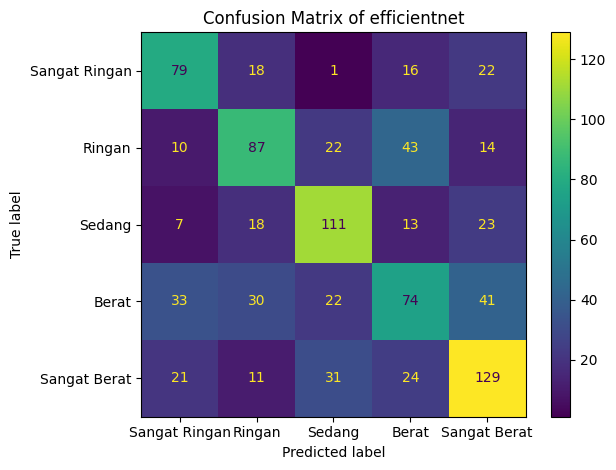

Accuracy of efficientnet           : 0.5333
Precision Per Class of efficientnet: [0.52666667 0.5304878  0.59358289 0.43529412 0.56331878]
Macro Precision     of efficientnet: 0.5299
Micro Precision     of efficientnet: 0.5333
Recall Per Class  of efficientnet  : [0.58088235 0.49431818 0.64534884 0.37       0.59722222]
Macro Recall      of efficientnet  : 0.5376
Micro Recall      of efficientnet  : 0.5333
F1-Score Per Class of efficientnet : [0.55244755 0.51176471 0.6183844  0.4        0.57977528]
Macro F1-Score of efficientnet     : 0.5325
Micro F1-Score of efficientnet     : 0.5333


In [38]:
# === MAKING PREDICTION ===

model_names = ['efficientnet']#, 'shufflenet', 'mobilenet', 'squeezenet']
model_categories = ['best_tuned']# , 'baseline']

# mapping folder evaluasi tiap model
evaluation_dirs_baseline = {
    "mobilenet": "/home/g6422078/Evaluation/Mobilenet V3-Small/Baseline",
    "squeezenet": "/home/g6422078/Evaluation/SqueezeNet V1.1/Baseline",
    "shufflenet": "/home/g6422078/Evaluation/ShuffleNetV2-x0.5/Baseline",
    "efficientnet": "/home/g6422078/Evaluation/EfficientNet-Lite0/Baseline"
}

evaluation_dirs_best = {
    "mobilenet": "/home/g6422078/Evaluation/Mobilenet V3-Small/Best Model",
    "squeezenet": "/home/g6422078/Evaluation/SqueezeNet V1.1/Best Model",
    "shufflenet": "/home/g6422078/Evaluation/ShuffleNetV2-x0.5/Best Model",
    "efficientnet": "/home/g6422078/Evaluation/EfficientNet-Lite0/Best Model"
}

for model_name, model_category in product(model_names, model_categories):
    model = prepare_model(model_name, model_category)
    model.to(device)
    
    if model_category == 'baseline':
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    elif model_category == 'best_tuned':
        if model_name == 'mobilenet':
            test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        elif model_name == 'squeezenet':
            test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        elif model_name == 'efficientnet':
            test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        elif model_name == 'shufflenet':
            test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    test_loss = 0 
    all_preds_test, all_labels_test = [], []
    criterion = nn.CrossEntropyLoss()

    # put model in eval mode 
    model.eval()

    with torch.no_grad(): # turn on no_grad() for faster performance bc it disables gradient tracking functionality (gradient tracking is not needed for inference)
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs) # forward pass
            if model_name == "squeezenet": # flatten untuk mengubah output model squeezenet dari [batch, jumlah kelas, 1, 1] menjadi [batch, jumlah kelas] yang bisa diterima oleh loss function crossentropy loss 
                outputs = outputs.view(outputs.size(0), -1)

            #calculate loss
            loss = criterion(outputs, labels) 
            test_loss += loss.item()

            preds = torch.argmax(outputs, dim=1).cpu().numpy() # Ambil kelas dengan probabilitas tertinggi dari output model, ubah jadi CPU (karena .numpy() hanya bisa dipakai di CPU), kemudian ubah jadi array NumPy 

            # accumulate predictions and labels into a single Python list across multiple batches
            all_preds_test.extend(preds)
            all_labels_test.extend(labels.cpu().numpy()) 
    avg_test_loss = test_loss/len(test_loader)
    print(f"Average Test Loss of {model_name}  : {avg_test_loss:.4f}")
    
    # confusion matrix
    ordered_labels = [0,3,2,1,4]
    
    # nama label sesuai urutan di atas
    class_names = [
        "Sangat Ringan",
        "Ringan",
        "Sedang",
        "Berat",
        "Sangat Berat"
    ]
    
    # buat confusion matrix dengan label yang telah disesuaikan
    confmatr = confusion_matrix(all_labels_test, all_preds_test, labels=ordered_labels)
    
    # display the confusion matrix
    confmatr_display = ConfusionMatrixDisplay(confusion_matrix=confmatr, display_labels=class_names)
    
    confmatr_display.plot()
    plt.title(f'Confusion Matrix of {model_name}')
    
    plt.tight_layout()
    '''
    # ambil direktori model
    if model_category == 'baseline':
        save_dir = evaluation_dirs_baseline[model_name]
    elif model_category == 'best_tuned':
        save_dir = evaluation_dirs_best[model_name]
    
    # bikin folder jika belum ada
    os.makedirs(save_dir, exist_ok=True)
    
    # susun path confusion matrix model 
    cm_path = os.path.join(
        save_dir,
        f"{model_name}_{model_category}_confusion_matrix.png"
    )
        
    # save confusion matrix model
    plt.savefig(cm_path)
    '''
        
    plt.show()
    
    plt.close()
    
    # metriks evaluasi akurasi --> normalize = True (default) to turn it into a percentage, sisanya gak perlu di-tuning
    acc = accuracy_score(all_labels_test, all_preds_test)
    print(f"Accuracy of {model_name}           : {acc:.4f}")
    
    # metriks evaluasi precision
    # precision per kelas --> average = None
    precision_per_class = precision_score(all_labels_test, all_preds_test, labels=ordered_labels, average=None, zero_division=0)
    # precision macro average --> average = macro
    precision_macro = precision_score(all_labels_test, all_preds_test, labels=ordered_labels, average='macro', zero_division=0)
    # precision micro average --> average = micro
    precision_micro = precision_score(all_labels_test, all_preds_test, labels=ordered_labels, average='micro',zero_division=0)
    print(f"Precision Per Class of {model_name}: {precision_per_class}")
    print(f"Macro Precision     of {model_name}: {precision_macro:.4f}")
    print(f"Micro Precision     of {model_name}: {precision_micro:.4f}")
    
    # metriks evaluasi recall
    # recall per kelas --> average = None
    recall_per_class = recall_score(all_labels_test, all_preds_test, labels=ordered_labels, average=None,zero_division=0)
    # recall macro average --> average = macro
    recall_macro = recall_score(all_labels_test, all_preds_test, labels=ordered_labels, average='macro',zero_division=0)
    # recall micro average --> average = micro
    recall_micro = recall_score(all_labels_test, all_preds_test, labels=ordered_labels, average='micro',zero_division=0)
    print(f"Recall Per Class  of {model_name}  : {recall_per_class}")
    print(f"Macro Recall      of {model_name}  : {recall_macro:.4f}")
    print(f"Micro Recall      of {model_name}  : {recall_micro:.4f}")
    
    # metriks evaluasi f1 score
    # f1 score per kelas --> average = None
    f1_per_class = f1_score(all_labels_test, all_preds_test, labels=ordered_labels, average=None,zero_division=0)
    # f1 score macro average --> average = macro
    f1_macro = f1_score(all_labels_test, all_preds_test, labels=ordered_labels, average='macro',zero_division=0)
    # f1 score micro average --> average = micro
    f1_micro = f1_score(all_labels_test, all_preds_test, labels=ordered_labels, average='micro',zero_division=0)
    print(f"F1-Score Per Class of {model_name} : {f1_per_class}")
    print(f"Macro F1-Score of {model_name}     : {f1_macro:.4f}")
    print(f"Micro F1-Score of {model_name}     : {f1_micro:.4f}")
    
    # simpan data all_labels_test dan all_preds_test
    # ubah list ke 
    
    # simpan ke folder setiap model 
    
    
    '''
    # ubah metric per class jadi dictionary label:value
    precision_per_class_dict = {
        class_name: float(score)
        for class_name, score in zip(class_names, precision_per_class)
    }

    recall_per_class_dict = {
        class_name: float(score)
        for class_name, score in zip(class_names, recall_per_class)
    }

    f1_per_class_dict = {
        class_name: float(score)
        for class_name, score in zip(class_names, f1_per_class)
    }
    '''


    
    # save hasil evaluasi ke json
    evaluation_result = {
        "average_test_loss": avg_test_loss,
        
        "accuracy": acc,
        
        "precision": {
            "precision_per_class": precision_per_class, #precision_per_class_dict,
            "macro_average_precision": precision_macro,
            "micro_average_precision": precision_micro
        },
        
        "recall": {
            "recall_per_class": recall_per_class, #recall_per_class_dict,
            "macro_average_recall": recall_macro,
            "micro_average_recall": recall_micro       
        },
        
        "f1_score": {
            "f1_score_per_class": f1_per_class, #f1_per_class_dict,
            "macro_average_f1_score": f1_macro,
            "micro_average_f1_score": f1_micro          
        }
    }
    
    '''
    # susun path json evaluasi
    json_path = os.path.join(
        save_dir,
        f"{model_name}_{model_category}_evaluation.json"
    )
    
    # save json evaluasi 
    with open(json_path, "w") as f:
        json.dump(evaluation_result, f, indent=4)

    
    print(f"\nEvaluation result saved to:")
    print(json_path)
    '''



Plot saved to:
/home/g6422078/Evaluation/f1_score_comparison_baseline.png


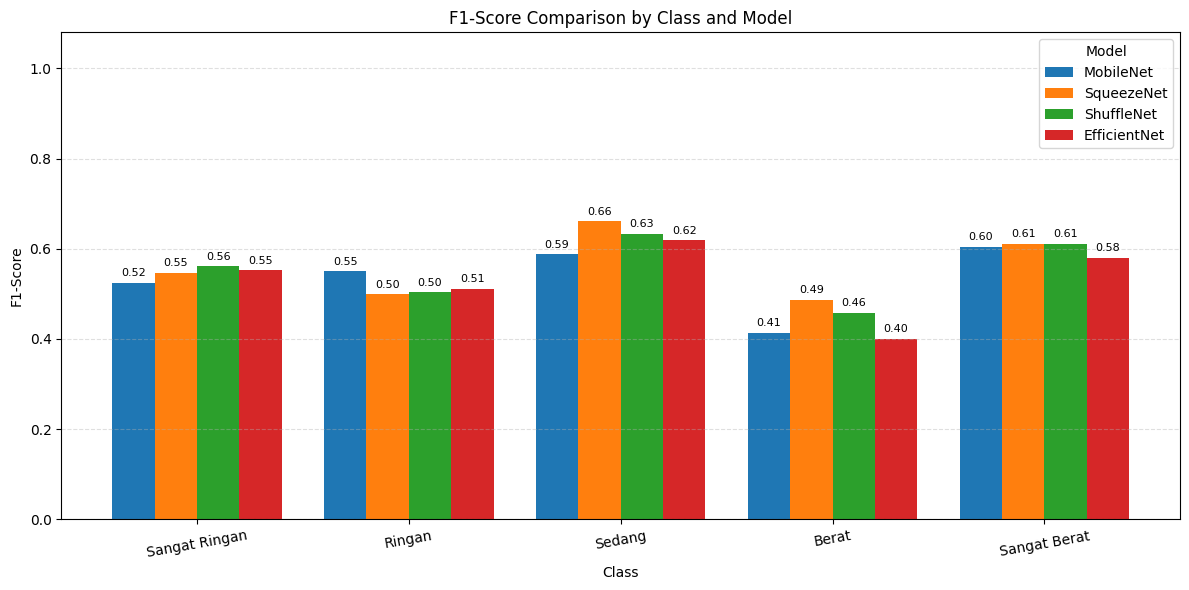

In [48]:
# BELUM DIBUAT CONDITIONAL MATCHING BASELINE DENGAN BEST TUNED MODEL, HARUS DIATUR MANUAL (KALO MAU EVALUASI BEST TUNED, MODEL_PATHS GANTI KE YANG BEST TUNED, VICE VERSA)

# print perbandingan f1 score setiap kelas accross models
import json
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PATH JSON
# =========================

model_paths = {
    # baseline model
    #"MobileNet": "/home/g6422078/Evaluation/Mobilenet V3-Small/Baseline/mobilenet_baseline_evaluation.json",

    #"SqueezeNet": "/home/g6422078/Evaluation/SqueezeNet V1.1/Baseline/squeezenet_baseline_evaluation.json",

    #"ShuffleNet": "/home/g6422078/Evaluation/ShuffleNetV2-x0.5/Baseline/shufflenet_baseline_evaluation.json",

    #"EfficientNet": "/home/g6422078/Evaluation/EfficientNet-Lite0/Baseline/efficientnet_baseline_evaluation.json"
    
    # best tuned model
    "MobileNet": "/home/g6422078/Evaluation/Mobilenet V3-Small/Best Model/mobilenet_best_tuned_evaluation.json",

    "SqueezeNet": "/home/g6422078/Evaluation/SqueezeNet V1.1/Best Model/squeezenet_best_tuned_evaluation.json",

    "ShuffleNet": "/home/g6422078/Evaluation/ShuffleNetV2-x0.5/Best Model/shufflenet_best_tuned_evaluation.json",

    "EfficientNet": "/home/g6422078/Evaluation/EfficientNet-Lite0/Best Model/efficientnet_best_tuned_evaluation.json"
}

# =========================
# NAMA KELAS
# sesuai urutan confusion matrix terbaru
# =========================

class_names = [
    "Sangat Ringan",
    "Ringan",
    "Sedang",
    "Berat",
    "Sangat Berat"
]

# =========================
# LOAD F1-SCORE
# =========================

f1_scores = {}

for model_name, path in model_paths.items():
    with open(path, "r") as f:
        data = json.load(f)

    # ambil f1 per class
    scores = data["f1_score"]["f1_score_per_class"]

    # reorder supaya severity urut
    # encoding asli:
    # 0 = Sangat Ringan
    # 1 = Berat
    # 2 = Sedang
    # 3 = Ringan
    # 4 = Sangat Berat

    '''
    reordered_scores = [
        scores[0],  # Sangat Ringan
        scores[3],  # Ringan
        scores[2],  # Sedang
        scores[1],  # Berat
        scores[4]   # Sangat Berat
    ]
    '''

    f1_scores[model_name] = scores #reordered_scores

# =========================
# MULTI BAR CHART
# =========================

x = np.arange(len(class_names))
width = 0.2

plt.figure(figsize=(12,6))

models = list(f1_scores.keys())

for i, model_name in enumerate(models):

    offset = (i - (len(models)-1)/2) * width

    bars = plt.bar(
        x + offset,
        f1_scores[model_name],
        width=width,
        label=model_name
    )
    # =========================
    # TAMBAHKAN ANGKA DI ATAS BAR
    # =========================

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,  # posisi x
            height + 0.01,                    # posisi y
            f"{height:.2f}",                 # 2 angka desimal
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=0
        )

# =========================
# CUSTOMIZATION
# =========================

plt.xticks(x, class_names, rotation=10)

plt.ylabel("F1-Score")
plt.xlabel("Class")

plt.title("F1-Score Comparison by Class and Model")

plt.ylim(0, 1.08)  # kasih ruang supaya angka gak kepotong

plt.legend(title="Model")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

# =========================
# SAVE
# =========================

#NAMA BASELINE
#save_path = "/home/g6422078/Evaluation/f1_score_comparison_baseline.png"

#NAMA BEST MODEL
#save_path = "/home/g6422078/Evaluation/f1_score_comparison_best_model.png"

plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"Plot saved to:\n{save_path}")

plt.show()

plt.close()

## Ukuran model

In [19]:
# ukuran model

import torch
import os

# berdasarkan jumlah parameter
'''
kerangka:
loop:
- ambil angka dari jumlah parameter dari setiap model
- ambil angka 
'''
model_names = ['shufflenet', 'mobilenet', 'squeezenet', 'efficientnet']
model_categories = ['baseline', 'best_tuned']

model_size_dirs_baseline = {
    "mobilenet": "/home/g6422078/Evaluation/Mobilenet V3-Small/Baseline",
    "squeezenet": "/home/g6422078/Evaluation/SqueezeNet V1.1/Baseline",
    "shufflenet": "/home/g6422078/Evaluation/ShuffleNetV2-x0.5/Baseline",
    "efficientnet": "/home/g6422078/Evaluation/EfficientNet-Lite0/Baseline"
}

model_size_dirs_best = {
    "mobilenet": "/home/g6422078/Evaluation/Mobilenet V3-Small/Best Model",
    "squeezenet": "/home/g6422078/Evaluation/SqueezeNet V1.1/Best Model",
    "shufflenet": "/home/g6422078/Evaluation/ShuffleNetV2-x0.5/Best Model",
    "efficientnet": "/home/g6422078/Evaluation/EfficientNet-Lite0/Best Model"
}

def count_parameters(state_dict):
    return sum(param.numel() for param in state_dict.values())

for model_name, model_category in product(model_names,model_categories):
    if model_name == 'mobilenet':
        if model_category == 'baseline':
            path = "/home/g6422078/Modelling/MobileNet Modelling Result/Baseline/models/bs32_do0.2_lr0.001_modelmobilenet_optadam.pth"
        elif model_category == 'best_tuned':
            path = "/home/g6422078/Evaluation/Mobilenet V3-Small/Best Model/best_mobilenet.pth"
    elif model_name == 'squeezenet':
        if model_category == 'baseline':
            path = "/home/g6422078/Modelling/SqueezeNet Modelling Result/Baseline/models/bs32_do0.2_lr0.001_modelsqueezenet_optadam.pth"
        elif model_category == 'best_tuned':
            path = "/home/g6422078/Evaluation/SqueezeNet V1.1/Best Model/best_squeezenet.pth"
    elif model_name == 'efficientnet':
        if model_category == 'baseline':
            path = "/home/g6422078/Modelling/EfficientNet Modelling Result/Baseline/models/bs32_do0.2_lr0.001_modelefficientnet_optadam.pth"
        elif model_category == 'best_tuned':
            path = "/home/g6422078/Evaluation/EfficientNet-Lite0/Best Model/best_efficientnet.pth"
    elif model_name == 'shufflenet':
        if model_category == 'baseline':
            path = "/home/g6422078/Modelling/ShuffleNet Modelling Result/Baseline/models/bs32_do0.2_lr0.001_modelshufflenet_optadam.pth"
        elif model_category == 'best_tuned':
            path = "/home/g6422078/Evaluation/ShuffleNetV2-x0.5/Best Model/best_shufflenet.pth"
    
    # load state_dict
    state_dict = torch.load(path, map_location='cpu')
    
    # hitung jumlah parameter
    total_params = count_parameters(state_dict)
    
    # hitung model size: # of parameters dari model x 4 (semua model pytorch yg aku pake dibangun dari float32)
    size_mb = total_params * 4 / (1024**2)
    
    # ukuran file asli # --> out of curiosity, mau tau apakah model size bds perhitungan jumlah parameter x ukuran floating point data type sama dengan ukuran file model.
    file_size_mb = os.path.getsize(path) / (1024**2) # kalo ternyata ukurannya sama, pake metode perhitungan jumlah parameter x ukuran floating point --> catet metodenya di draft skripsi. kalo ternyata beda, pake yang ukuran file dan gausah dicatet caranya (liat ukuran file) di draft skripsi [sebagaimana tesis bang abin]
    
    print(f"Model: {model_name} ({model_category})")
    print(f"  Total parameters : {total_params:,}")
    print(f"  Model Size       : {size_mb:.2f} MB")
    print(f"  File size actual : {file_size_mb:.2f} MB")
    print("-" * 40)
    
        # data json
    model_size_info = {
        "total_parameters": int(total_params),
        "model_size_mb": round(size_mb, 4),
        "actual_file_size_mb": round(file_size_mb, 4)
    }

    # tentukan folder output
    if model_category == "baseline":
        save_dir = model_size_dirs_baseline[model_name]
    else:
        save_dir = model_size_dirs_best[model_name]

    os.makedirs(save_dir, exist_ok=True)

    # simpan json
    save_path = os.path.join(save_dir, f"model_size_{model_category}_{model_name}.json")

    with open(save_path, "w") as f:
        json.dump(model_size_info, f, indent=4)

    print(f"Saved: {save_path}")

Model: shufflenet (baseline)
  Total parameters : 354,925
  Model Size       : 1.35 MB
  File size actual : 1.48 MB
----------------------------------------
Saved: /home/g6422078/Evaluation/ShuffleNetV2-x0.5/Baseline/model_size_baseline_shufflenet.json
Model: shufflenet (best_tuned)
  Total parameters : 354,925
  Model Size       : 1.35 MB
  File size actual : 1.46 MB
----------------------------------------
Saved: /home/g6422078/Evaluation/ShuffleNetV2-x0.5/Best Model/model_size_best_tuned_shufflenet.json
Model: mobilenet (baseline)
  Total parameters : 1,535,127
  Model Size       : 5.86 MB
  File size actual : 5.95 MB
----------------------------------------
Saved: /home/g6422078/Evaluation/Mobilenet V3-Small/Baseline/model_size_baseline_mobilenet.json
Model: mobilenet (best_tuned)
  Total parameters : 1,535,127
  Model Size       : 5.86 MB
  File size actual : 5.94 MB
----------------------------------------
Saved: /home/g6422078/Evaluation/Mobilenet V3-Small/Best Model/model_size_